In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [33]:

# Load dataset
# data = pd.read_excel("C:\\Users\\AMT\\Desktop\\Selected Articles\\cleaned_data.xlsx", engine="openpyxl")
file_path = r"H:\Master Files\cleaned_data.xlsx"

# Read the Excel file
data = pd.read_excel(file_path, engine="openpyxl")

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1923 entries, 0 to 1922
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   CASE_NO_PATIENT'S                                   1923 non-null   int64 
 1   A1                                                  1923 non-null   int64 
 2   A2                                                  1923 non-null   int64 
 3   A3                                                  1923 non-null   int64 
 4   A4                                                  1923 non-null   int64 
 5   A5                                                  1923 non-null   int64 
 6   A6                                                  1923 non-null   int64 
 7   A7                                                  1923 non-null   int64 
 8   A8                                                  1923 non-null   int64 
 9   A9      

In [4]:
data.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000
mean,990.641706,0.302132,0.241810,0.215289,0.274571,0.279771,0.306292,0.347374,0.246490,0.261050,0.453458,3.141966,9.611024,4.217369,1.712949
std,577.501297,0.459302,0.428291,0.411129,0.446414,0.449003,0.461073,0.476260,0.431079,0.439322,0.497959,3.703518,4.310228,2.895612,1.022013
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,483.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,984.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1493.500000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,6.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


In [5]:
data.isnull().sum()

CASE_NO_PATIENT'S                                     0
A1                                                    0
A2                                                    0
A3                                                    0
A4                                                    0
A5                                                    0
A6                                                    0
A7                                                    0
A8                                                    0
A9                                                    0
A10_Autism_Spectrum_Quotient                          0
Social_Responsiveness_Scale                           0
Age_Years                                             0
Qchat_10_Score                                        0
Speech Delay/Language Disorder                        0
Learning disorder                                     0
Genetic_Disorders                                     0
Depression                                      

In [6]:
data.shape

(1923, 28)

In [8]:
# Step 4: Feature Selection
X = data.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = data["ASD_traits"]  # Target

In [35]:
X = pd.get_dummies(X, drop_first=True)  # Convert categorical features into dummy variables

In [36]:
# Import necessary libraries
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features based on ANOVA F-statistic
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'Qchat_10_Score'], dtype='object')


In [37]:

# Handle missing values
data = data.dropna()


In [38]:
# Encode categorical variables
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [39]:
# Define features and target variable
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [40]:
# Encode target variable if necessary
if y.dtype == 'object':
    le_y = LabelEncoder()
    y = le_y.fit_transform(y)

In [41]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Initialize classifiers
nb_model = GaussianNB()
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss')
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)

In [43]:
# Train models
nb_model.fit(X_train, y_train)
adaboost_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:00:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=42)

In [44]:
# Train models
nb_model.fit(X_train, y_train)
adaboost_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:00:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=42)

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# Train models
nb_model = GaussianNB()
ada_model = AdaBoostClassifier()
xgb_model = XGBClassifier()
lgbm_model = LGBMClassifier()

nb_model.fit(X_train, y_train)
ada_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_ada = ada_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgbm = lgbm_model.predict(X_test)

# Accuracy scores
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Naïve Bayes Accuracy: 0.7064935064935065
AdaBoost Accuracy: 0.9844155844155844
XGBoost Accuracy: 0.9974025974025974
LightGBM Accuracy: 0.99480519

In [58]:
# # Accuracy scores
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))

Naïve Bayes Accuracy: 0.7064935064935065
AdaBoost Accuracy: 0.9844155844155844
XGBoost Accuracy: 0.9974025974025974
LightGBM Accuracy: 0.9948051948051948


In [60]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import jaccard_score, mean_squared_error

In [61]:
# Import necessary libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, mean_squared_error

# Initialize classifiers (Fix base_estimator issue)
nb_model = GaussianNB()
adaboost_nb = AdaBoostClassifier(estimator=GaussianNB(), n_estimators=50, random_state=42)  # Fixed parameter name
xgb_model = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)

# Train models
nb_model.fit(X_train, y_train)
adaboost_nb.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_adaboost_nb = adaboost_nb.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgbm = lgbm_model.predict(X_test)

# Define evaluation function
def evaluate_model(y_true, y_pred, model_name, model=None):
    print(f"--- Evaluating {model_name} ---")
    print(f"{model_name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{model_name} F1 Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"{model_name} Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"{model_name} Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"{model_name} Jaccard Score: {jaccard_score(y_true, y_pred, average='macro'):.4f}")
    print(f"{model_name} Mean Squared Error (MSE): {mean_squared_error(y_true, y_pred):.4f}\n")

# Evaluate models
evaluate_model(y_test, y_pred_nb, "Naïve Bayes", nb_model)
evaluate_model(y_test, y_pred_adaboost_nb, "AdaBoost (Naïve Bayes)", adaboost_nb)
evaluate_model(y_test, y_pred_xgb, "XGBoost", xgb_model)
evaluate_model(y_test, y_pred_lgbm, "LightGBM", lgbm_model)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- Evaluating Naïve Bayes ---
Naïve Bayes Accuracy: 0.7065
Naïve Bayes F1 Score: 0.7071
Naïve Bayes Precision: 0.7182
Naïve Bayes Recall: 0.7065

In [62]:
# Import necessary libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, mean_squared_error
import numpy as np

# Initialize classifiers
nb_model = GaussianNB()
adaboost_nb = AdaBoostClassifier(estimator=GaussianNB(), n_estimators=50, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)

# Train models
nb_model.fit(X_train, y_train)
adaboost_nb.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_adaboost_nb = adaboost_nb.predict(X_test)  # Ensure this gives class labels (0/1)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgbm = lgbm_model.predict(X_test)

# Ensure labels are numeric arrays
y_test = np.array(y_test)
y_pred_adaboost_nb = np.array(y_pred_adaboost_nb)

# Evaluation function with MSE check
def evaluate_model(y_true, y_pred, model_name):
    try:
        print(f"--- Evaluating {model_name} ---")
        print(f"{model_name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
        print(f"{model_name} F1 Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
        print(f"{model_name} Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
        print(f"{model_name} Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
        print(f"{model_name} Jaccard Score: {jaccard_score(y_true, y_pred, average='macro'):.4f}")

        # Compute MSE safely
        mse = mean_squared_error(y_true, y_pred)
        print(f"{model_name} Mean Squared Error (MSE): {mse:.4f}\n")

    except Exception as e:
        print(f"⚠️ Error in computing MSE for {model_name}: {e}\n")

# Evaluate models
evaluate_model(y_test, y_pred_nb, "Naïve Bayes")
evaluate_model(y_test, y_pred_adaboost_nb, "AdaBoost (Naïve Bayes)")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_lgbm, "LightGBM")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- Evaluating Naïve Bayes ---
Naïve Bayes Accuracy: 0.7065
Naïve Bayes F1 Score: 0.7071
Naïve Bayes Precision: 0.7182
Naïve Bayes Recall: 0.7065

In [23]:
%who

AdaBoostClassifier	 GaussianNB	 LGBMClassifier	 LabelEncoder	 SelectKBest	 X	 XGBClassifier	 X_new	 X_test	 
X_train	 accuracy_score	 adaboost_model	 adaboost_nb	 categorical_columns	 col	 data	 epochs	 evaluate_model	 
f1_score	 f_classif	 file_path	 jaccard_score	 label_encoders	 le	 lgbm_model	 mean_squared_error	 nb_model	 
np	 pd	 plt	 precision_score	 recall_score	 selected_features	 selector	 train_loss	 train_test_split	 
val_loss	 xgb_model	 y	 y_pred_ada	 y_pred_adaboost_nb	 y_pred_lgbm	 y_pred_nb	 y_pred_xgb	 y_test	 
y_train	 


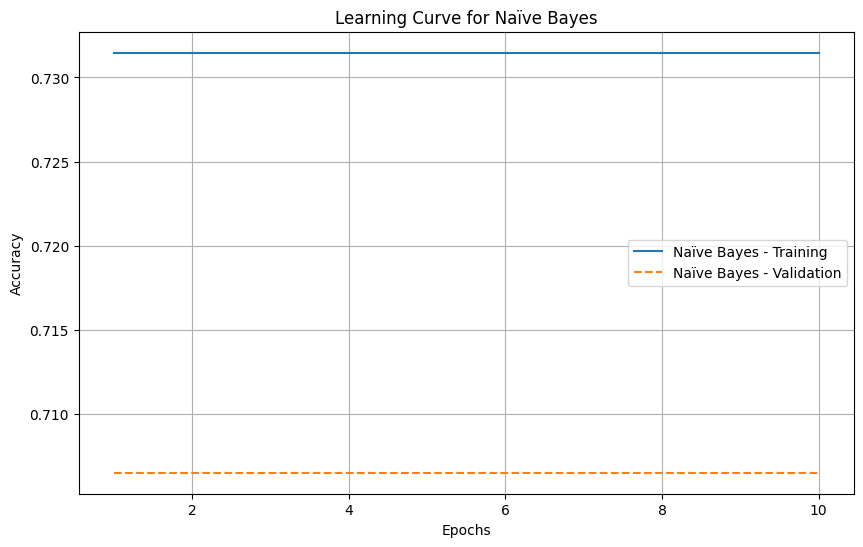

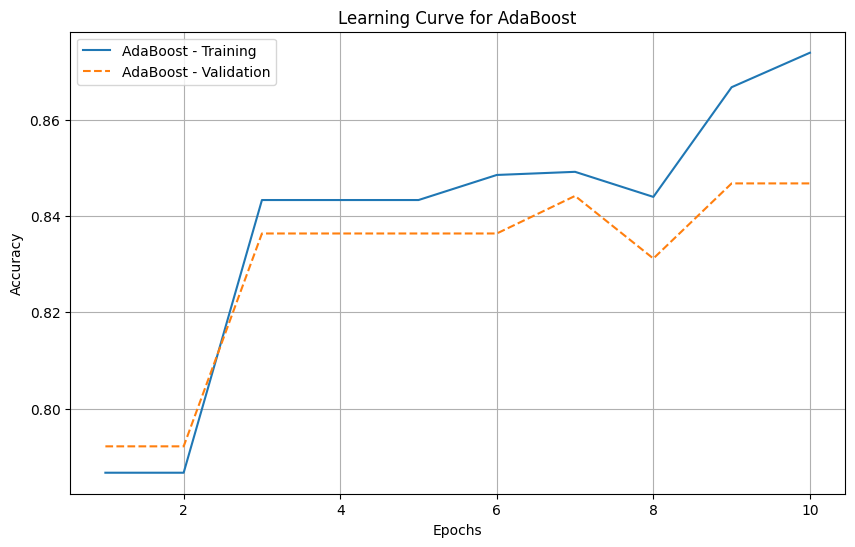

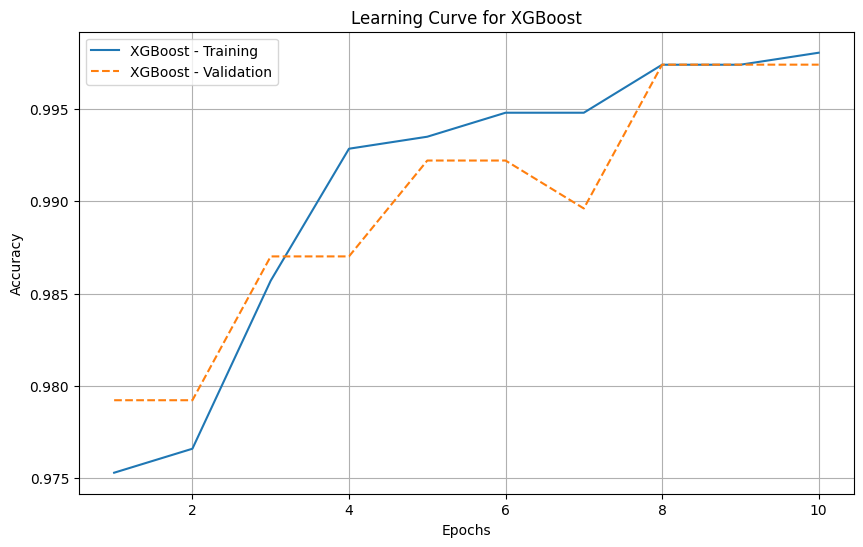

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005094 seconds.
You can set `force_col_wise=true` to remove 

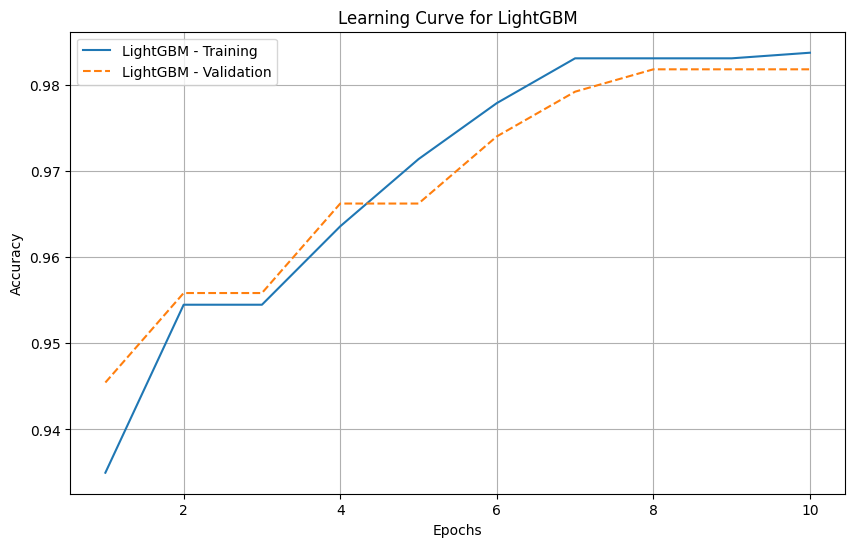

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define models (replace these with the actual model variables)
models = {
    "Naïve Bayes": nb_model,  
    "AdaBoost": adaboost_model,  
    "XGBoost": xgb_model,  
    "LightGBM": lgbm_model  
}

# Run multiple epochs to track accuracy
epochs = 10  # Adjust as needed

for name, model in models.items():
    train_accs = []
    val_accs = []

    # Track accuracy over epochs for each model
    for epoch in range(1, epochs + 1):
        
        # For models like AdaBoost, XGBoost, LightGBM, you can increase the number of boosting rounds/iterations
        if name == "AdaBoost":
            model.n_estimators = epoch  # AdaBoost has an `n_estimators` parameter to control boosting rounds
        elif name == "XGBoost":
            model.n_estimators = epoch  # XGBoost has `n_estimators` to control the number of boosting rounds
        elif name == "LightGBM":
            model.n_estimators = epoch  # LightGBM also uses `n_estimators` for the number of boosting rounds
        
        model.fit(X_train, y_train)  # Train the model with updated boosting rounds
        
        train_acc = accuracy_score(y_train, model.predict(X_train))
        val_acc = accuracy_score(y_test, model.predict(X_test))

        train_accs.append(train_acc)
        val_accs.append(val_acc)

    # Plot learning curves for each model separately
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs + 1), train_accs, label=f"{name} - Training")
    plt.plot(range(1, epochs + 1), val_accs, label=f"{name} - Validation", linestyle="dashed")
    
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve for {name}")
    plt.legend()
    plt.grid()
    plt.show()

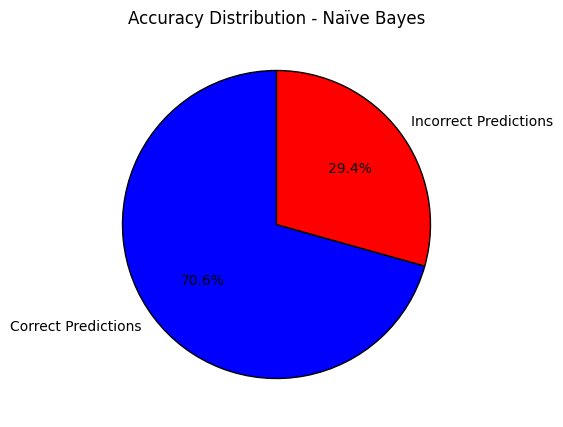

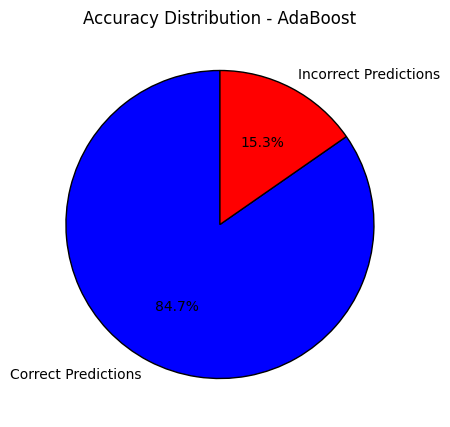

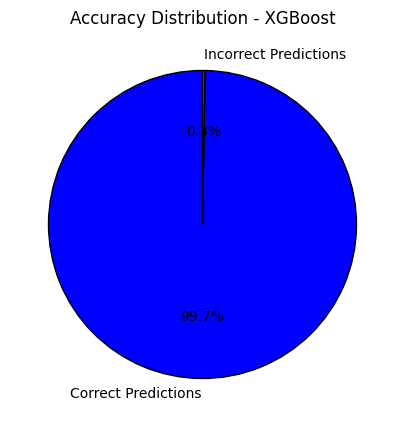

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


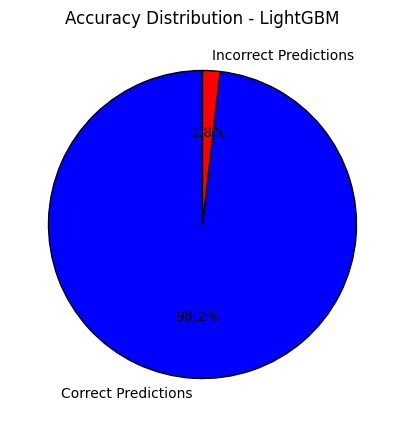

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define models (replace these with the actual model variables)
models = {
    "Naïve Bayes": nb_model,  
    "AdaBoost": adaboost_model,  
    "XGBoost": xgb_model,  
    "LightGBM": lgbm_model  
}

# Train and plot accuracy for each model separately
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Data for the pie chart (accuracy vs. error)
    labels = ["Correct Predictions", "Incorrect Predictions"]
    sizes = [accuracy, 1 - accuracy]  # Accuracy and error rate
    colors = ["blue", "red"]

    # Create a separate figure for each model
    plt.figure(figsize=(5, 5))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90, wedgeprops={"edgecolor": "black"})

    # Customize the plot
    plt.title(f"Accuracy Distribution - {name}")

    # Show the plot
    plt.show()

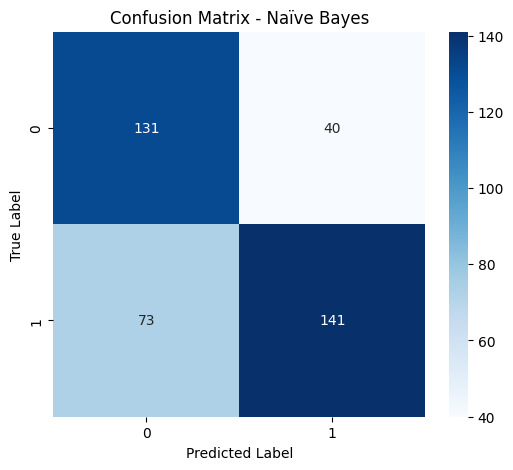

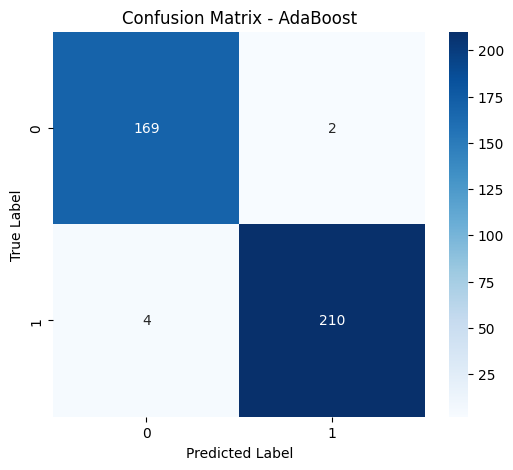

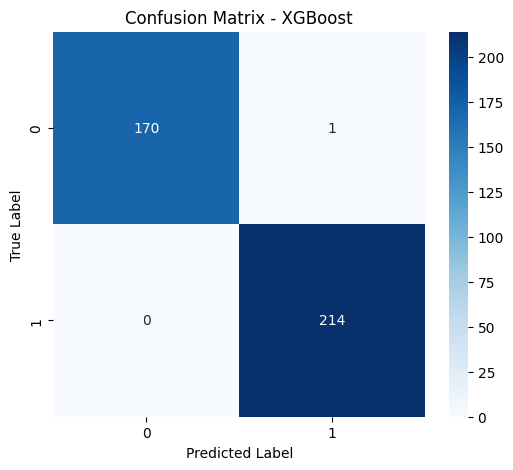

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


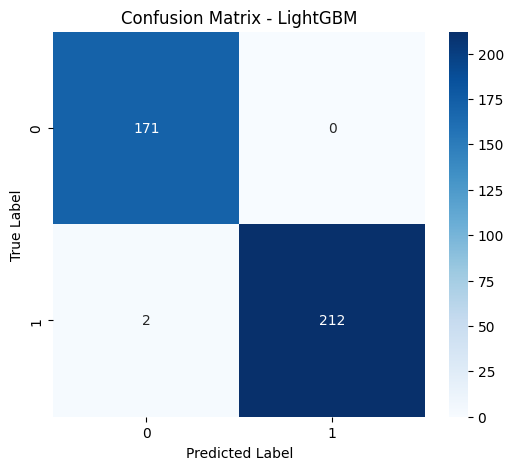

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import numpy as np

# Example: Initialize models
nb_model = GaussianNB()
adaboost_model = AdaBoostClassifier()
xgb_model = XGBClassifier()
lgbm_model = lgb.LGBMClassifier()

# Train/test data (make sure you have X_train, y_train, X_test, y_test)
# Replace with your actual dataset
# X_train, X_test, y_train, y_test = ...  # Load or define your dataset

# Define models (ensure these are the correct ones you initialized)
models = {
    "Naïve Bayes": nb_model,  
    "AdaBoost": adaboost_model,  
    "XGBoost": xgb_model,  
    "LightGBM": lgbm_model  
}

# Train and plot confusion matrix for each model separately
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    
    # Customize the plot
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    # Show the plot
    plt.show()

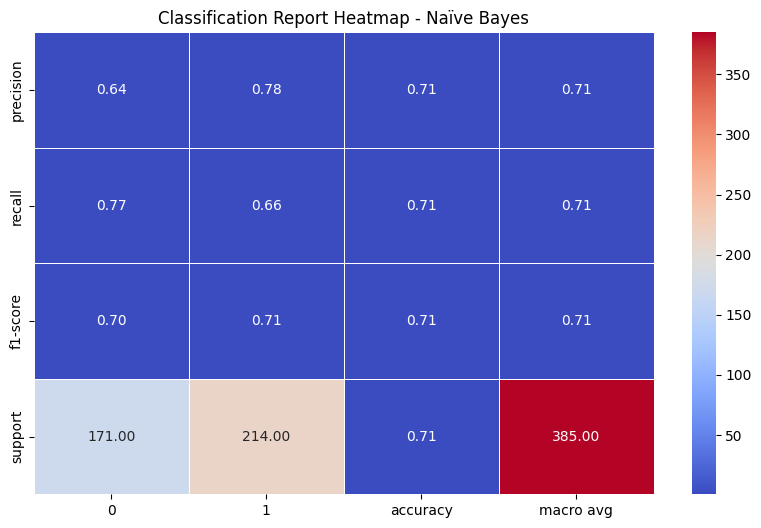

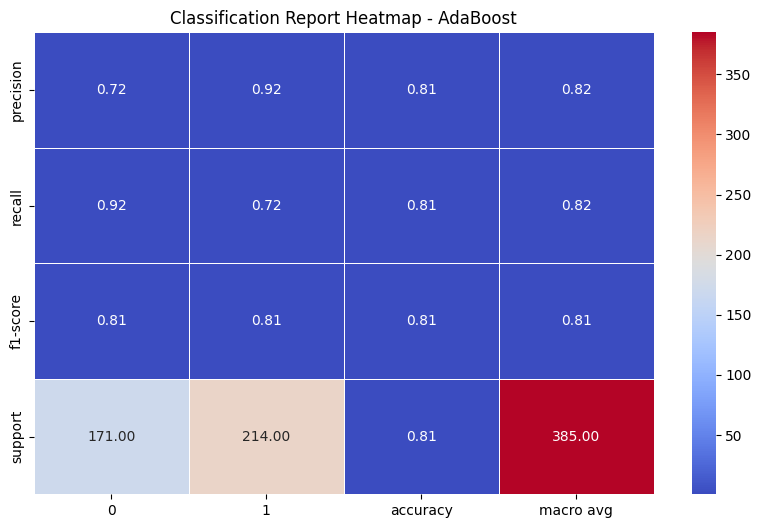

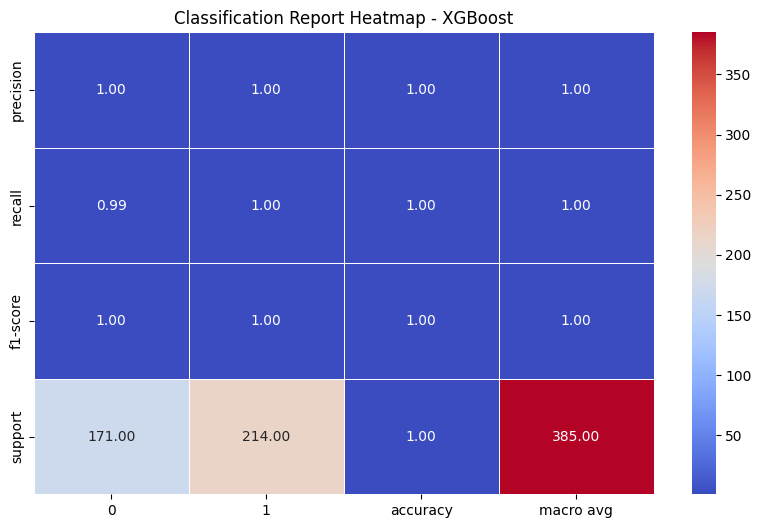

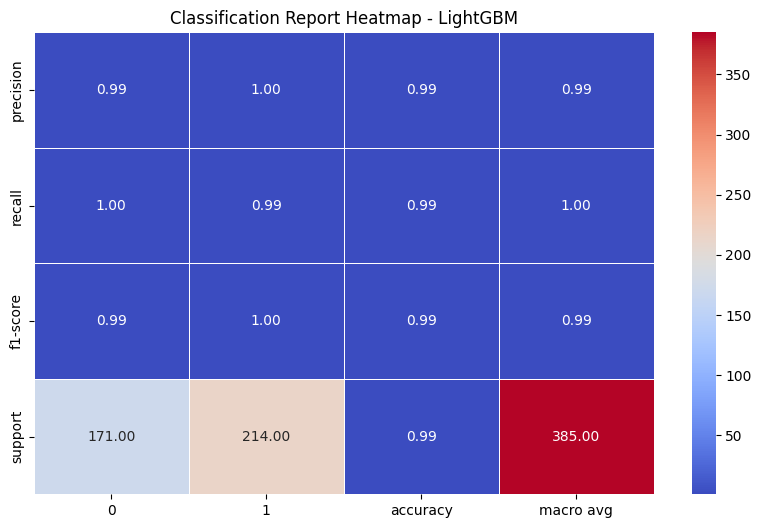

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Function to plot classification report heatmap
def plot_classification_report(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).T
    plt.figure(figsize=(10, 6))
    sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Classification Report Heatmap - {model_name}')
    plt.show()

# Plot heatmaps for each model
plot_classification_report(y_test, y_pred_nb, "Naïve Bayes")
plot_classification_report(y_test, y_pred_adaboost_nb, "AdaBoost")
plot_classification_report(y_test, y_pred_xgb, "XGBoost")
plot_classification_report(y_test, y_pred_lgbm, "LightGBM")

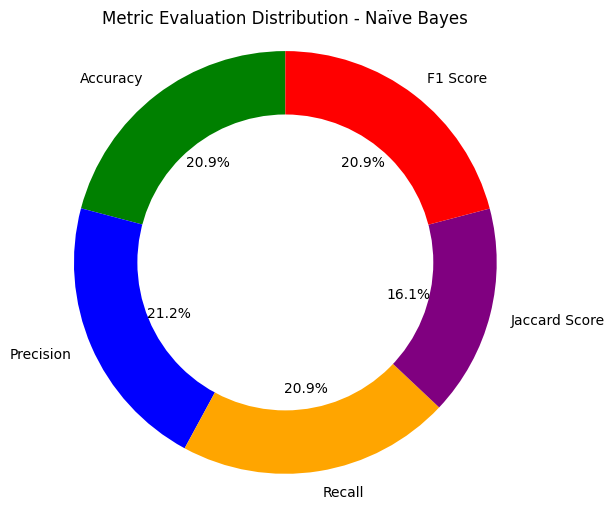

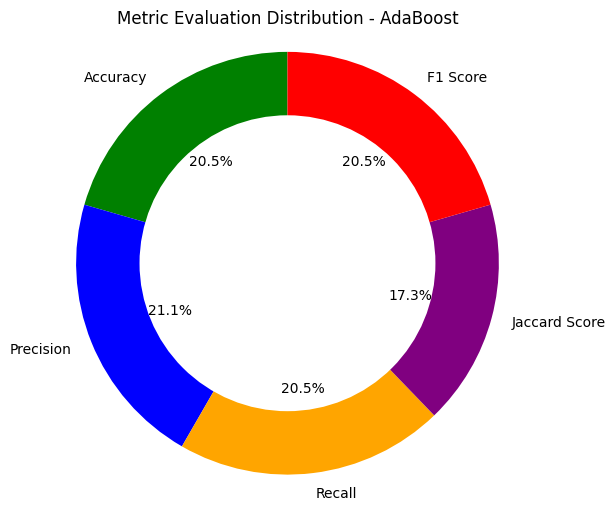

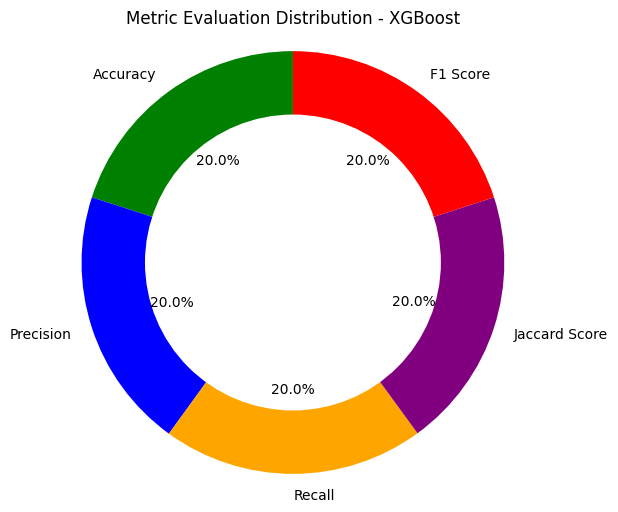

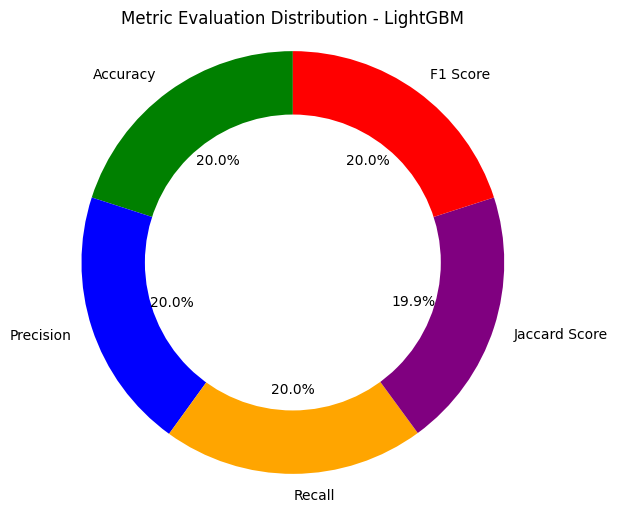

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, jaccard_score, f1_score

# Function to plot metrics as a donut chart for a single model
def plot_metrics_donut_single(model_name, accuracy, precision, recall, jaccard, f1):
    metrics = [accuracy, precision, recall, jaccard, f1]
    labels = ["Accuracy", "Precision", "Recall", "Jaccard Score", "F1 Score"]
    colors = ['green', 'blue', 'orange', 'purple', 'red']
    
    # Create a figure
    plt.figure(figsize=(6, 6))
    
    # Create the pie chart
    plt.pie(metrics, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    
    # Draw a circle in the center to make it a donut chart
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.axis('equal')
    
    # Title
    plt.title(f'Metric Evaluation Distribution - {model_name}')
    plt.show()

# Collect model evaluation scores
model_scores = {
    "Naïve Bayes": (
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        jaccard_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ),
    "AdaBoost": (
        accuracy_score(y_test, y_pred_adaboost_nb),
        precision_score(y_test, y_pred_adaboost_nb, average='weighted'),
        recall_score(y_test, y_pred_adaboost_nb, average='weighted'),
        jaccard_score(y_test, y_pred_adaboost_nb, average='macro'),
        f1_score(y_test, y_pred_adaboost_nb, average='weighted')
    ),
    "XGBoost": (
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted'),
        jaccard_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ),
    "LightGBM": (
        accuracy_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_lgbm, average='weighted'),
        recall_score(y_test, y_pred_lgbm, average='weighted'),
        jaccard_score(y_test, y_pred_lgbm, average='macro'),
        f1_score(y_test, y_pred_lgbm, average='weighted')
    )
}

# Plot donut charts for each model
for model, scores in model_scores.items():
    plot_metrics_donut_single(model, *scores)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not u

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 102
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 814, number of negative: 72

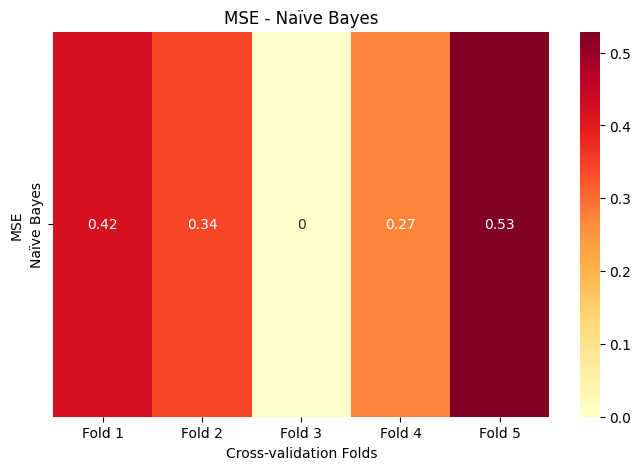

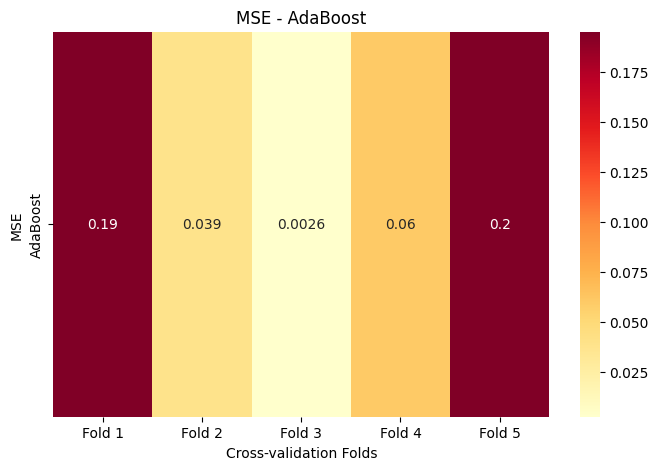

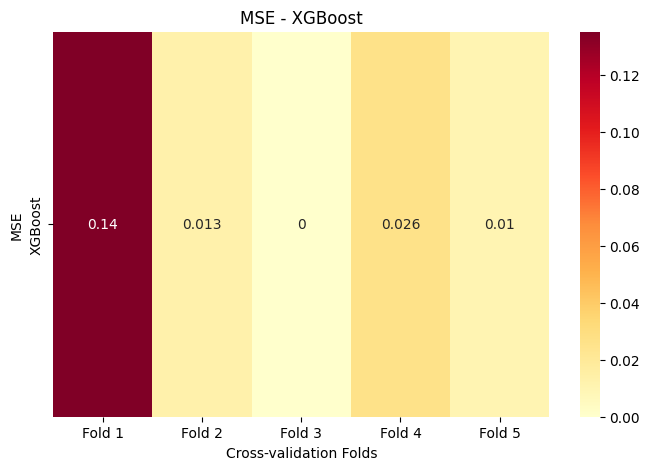

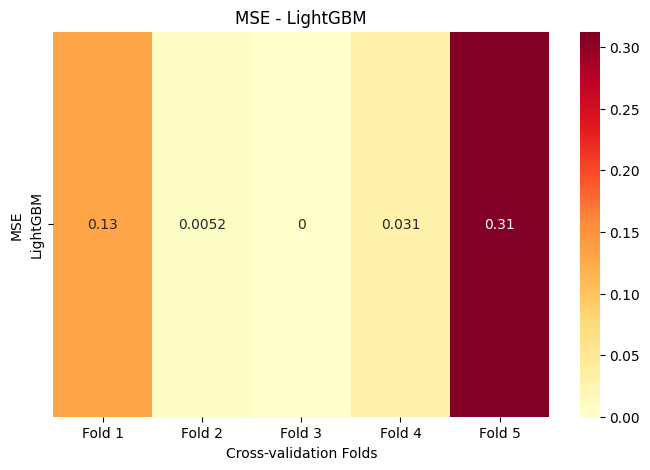

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset (replace this with your actual dataset)
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Drop irrelevant columns and preprocess
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

# Encode categorical variables
label_encoders = {}
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Feature selection (assuming 'ASD_traits' is the target)
X = df_cleaned.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = df_cleaned["ASD_traits"]  # Target

# Define models
nb_model = GaussianNB()
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss')
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)

# Create a custom scoring function for MSE
mse_scorer = make_scorer(mean_squared_error)

# Perform cross-validation to get MSE values for each model
cv_scores_nb = cross_val_score(nb_model, X, y, cv=5, scoring=mse_scorer)
cv_scores_adaboost = cross_val_score(adaboost_model, X, y, cv=5, scoring=mse_scorer)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring=mse_scorer)
cv_scores_lgbm = cross_val_score(lgbm_model, X, y, cv=5, scoring=mse_scorer)

# Visualization of MSE in a Single Rectangle for each model
def plot_mse_heatmap(cv_scores, model_name):
    plt.figure(figsize=(8, 5))
    sns.heatmap(cv_scores.reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
                xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores))], 
                yticklabels=[model_name])
    plt.title(f'MSE - {model_name}')
    plt.xlabel('Cross-validation Folds')
    plt.ylabel('MSE')
    plt.show()

# Plot MSE for each model
plot_mse_heatmap(cv_scores_nb, 'Naïve Bayes')
plot_mse_heatmap(cv_scores_adaboost, 'AdaBoost')
plot_mse_heatmap(cv_scores_xgb, 'XGBoost')
plot_mse_heatmap(cv_scores_lgbm, 'LightGBM')

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


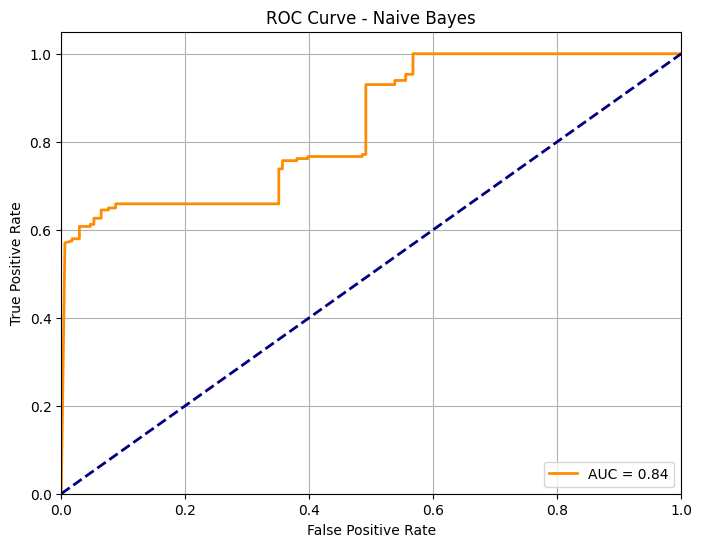

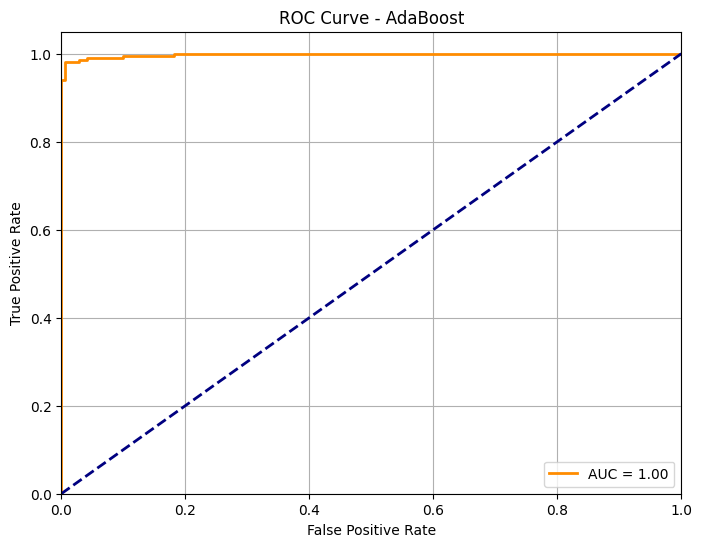

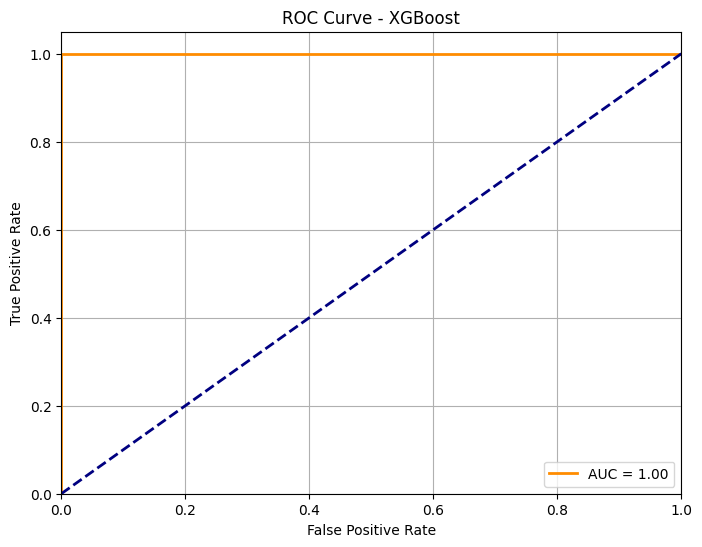

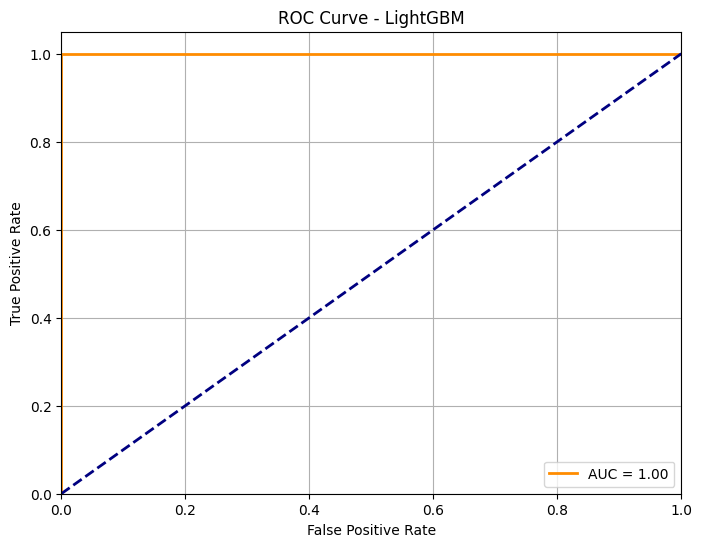

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Fit models
nb_model.fit(X_train, y_train)
adaboost_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train)

# Dictionary to hold models and their names
models = {
    "Naive Bayes": nb_model,
    "AdaBoost": adaboost_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

# Plot separate ROC curves for each model
for name, model in models.items():
    plt.figure(figsize=(8, 6))
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


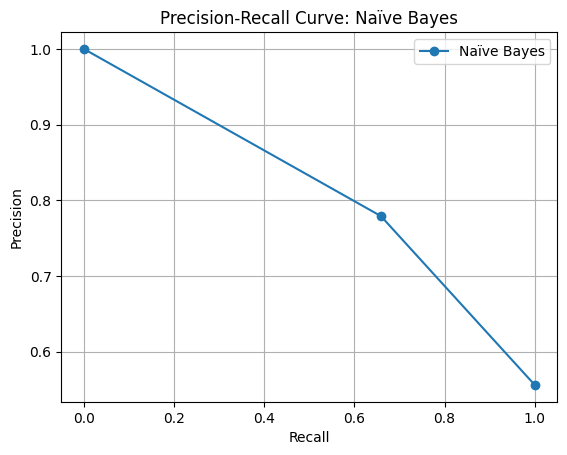

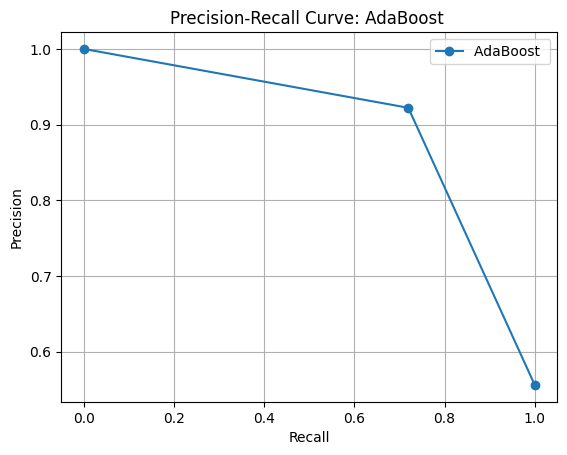

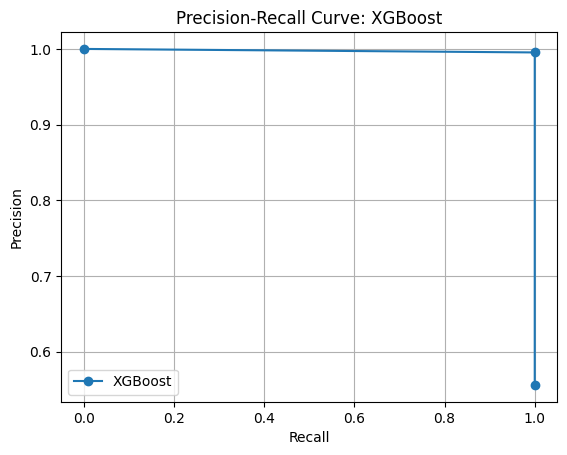

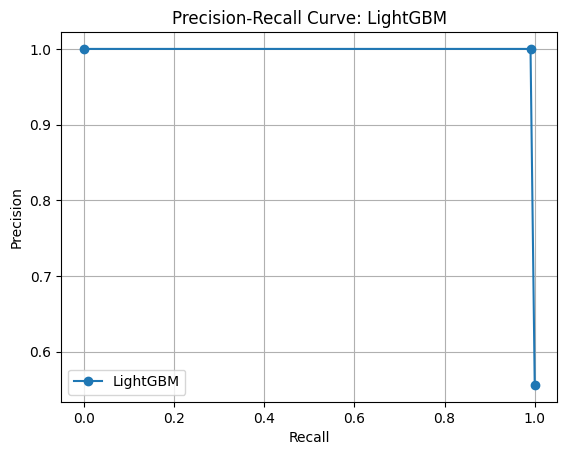

In [70]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Function to plot Precision-Recall curve for each model
def plot_precision_recall_curve(y_true, y_pred, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    plt.plot(recall, precision, marker='o', label=f'{model_name}')
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Plot Precision-Recall curve for Naïve Bayes
plot_precision_recall_curve(y_test, y_pred_nb, "Naïve Bayes")

# Plot Precision-Recall curve for AdaBoost with Naïve Bayes
plot_precision_recall_curve(y_test, y_pred_adaboost_nb, "AdaBoost ")

# Plot Precision-Recall curve for XGBoost
plot_precision_recall_curve(y_test, y_pred_xgb, "XGBoost")

# Plot Precision-Recall curve for LightGBM
plot_precision_recall_curve(y_test, y_pred_lgbm, "LightGBM")
